# Analyse out-of-sample : modèles entraînés sur annotations humaines, testés sur 1973 et 1981

Ce notebook évalue dans quelle mesure les modèles entraînés sur les **annotations humaines** (Henri, JL, Julien)
des législatives 1993 généralisent aux législatives de **1973** et **1981**.

**Pré-requis :** avoir exécuté `annotate_historique.py --year 1973` et `--year 1981`
pour disposer de `annotations_1973.xlsx` et `annotations_1981.xlsx`.

In [13]:
%pip install transformers accelerate wordcloud spacy scikit-learn openpyxl tqdm scipy evaluate datasets -q
import subprocess, sys
subprocess.run([sys.executable, '-m', 'spacy', 'download', 'fr_core_news_md'], check=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.6 MB/s eta 0:00:00


CompletedProcess(args=['/usr/bin/python3', '-m', 'spacy', 'download', 'fr_core_news_md'], returncode=0)

In [14]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import torch
from tqdm.notebook import tqdm
from scipy.stats import mannwhitneyu
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

warnings.filterwarnings('ignore')

device = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available()
          else 'cpu')
print(f'Device : {device}')

Device : cuda


---
## Section 0 — Chargement des données

In [15]:
# Chargement des annotations humaines (train)
df_h  = pd.read_excel('annotations Henri.xlsx').assign(source='Henri')
df_jl = pd.read_excel('annotations JL.xlsx').assign(source='JL')
df_ju = pd.read_excel('annotations Julien.xlsx').assign(source='Julien')

df_humain = pd.concat([df_h, df_jl, df_ju], ignore_index=True)
n_avant = len(df_humain)
df_humain = df_humain.drop_duplicates(subset=['Texte'], keep='first')
print(f'{n_avant - len(df_humain)} doublons supprimés — {len(df_humain)} segments uniques')

df_humain.columns = ['Parti', 'Courant Politique', 'Texte', 'Label', 'source']

# Chargement des datasets OOS
df_1973 = pd.read_excel('annotations_1973.xlsx').rename(columns={'Annotation LLM': 'Label'})
df_1981 = pd.read_excel('annotations_1981.xlsx').rename(columns={'Annotation LLM': 'Label'})
df_1973['annee'] = 1973
df_1981['annee'] = 1981

print('\n=== Statistiques descriptives ===')
for label, df in [('Humain (train)', df_humain), ('1973 (OOS)', df_1973), ('1981 (OOS)', df_1981)]:
    print(f'\n--- {label} ---')
    print(f'  N segments       : {len(df)}')
    print(f'  % langue de bois : {df["Label"].mean()*100:.1f}%')
    print(f'  Distribution courants :')
    print(df['Courant Politique'].value_counts().to_string())

9 doublons supprimés — 957 segments uniques

=== Statistiques descriptives ===

--- Humain (train) ---
  N segments       : 957
  % langue de bois : 69.0%
  Distribution courants :
Courant Politique
G     378
D     219
GR    178
DR     96
I      57
C      29

--- 1973 (OOS) ---
  N segments       : 252
  % langue de bois : 79.0%
  Distribution courants :
Courant Politique
I     59
C     48
GR    46
D     38
DR    32
G     29

--- 1981 (OOS) ---
  N segments       : 262
  % langue de bois : 76.7%
  Distribution courants :
Courant Politique
GR    129
I      40
C      38
D      26
G      16
DR     13


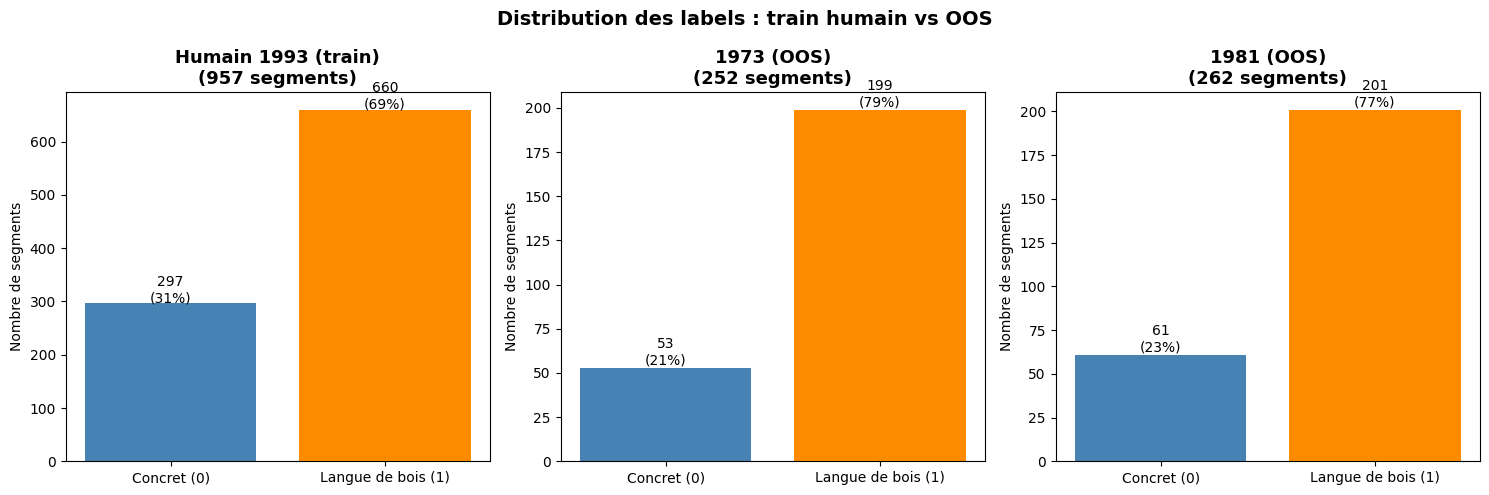

In [16]:
# Distribution des labels : train humain vs OOS 1973/1981
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, df) in zip(axes, [('Humain 1993 (train)', df_humain), ('1973 (OOS)', df_1973), ('1981 (OOS)', df_1981)]):
    counts = df['Label'].value_counts().sort_index()
    ax.bar(['Concret (0)', 'Langue de bois (1)'], counts.values, color=['steelblue', 'darkorange'])
    ax.set_title(f'{label}\n({len(df)} segments)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Nombre de segments')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 2, f'{v}\n({v/len(df)*100:.0f}%)', ha='center', fontsize=10)
plt.suptitle('Distribution des labels : train humain vs OOS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section I — Entraînement sur annotations humaines (Henri + JL + Julien)
*(même pipeline que notebook JL — features linguistiques + CamemBERT fine-tuné depuis camembert-base)*

In [17]:
nlp = spacy.load('fr_core_news_md')

def extraire_toutes_features(texte):
    if pd.isna(texte) or str(texte).strip() == '':
        return pd.Series({
            'texte_lemmatise': '', 'densite_valeurs_numeriques': 0,
            'densite_entites_institutionnelles': 0, 'densite_nominalisation': 0.0,
            'densite_futur_cond': 0.0, 'densite_interpellation': 0.0,
            'densite_emphase': 0.0, 'mots_par_phrase': 0.0, 'densite_ponct_interne': 0.0
        })

    texte_clean = re.sub(r'-\s*\n\s*', '', str(texte))
    texte_clean = re.sub(r'[·\-\_\r\n]+', ' ', texte_clean)
    texte_clean = re.sub(r'\s+', ' ', texte_clean).strip()
    doc = nlp(texte_clean)

    lemmes, longueur_mots = [], 0
    nb_noms_abstraits = nb_verbes_total = nb_verbes_futur_cond = 0
    nb_pronoms_interpellation = nb_adj_adv = nb_ponct_interne = 0

    mots_interpellation = {'nous', 'vous', 'notre', 'votre', 'nos', 'vos'}
    suffixes_abstraits  = ('tion', 'tions', 'ité', 'ités', 'isme', 'ismes', 'ment', 'ments')
    ponctuation_interne = {',', ';', ':'}

    nb_valeurs_numeriques        = sum(1 for t in doc if t.pos_ == 'NUM')
    nb_entites_institutionnelles = sum(1 for e in doc.ents if e.label_ in ['LOC', 'ORG'])

    for token in doc:
        if token.text in ponctuation_interne:
            nb_ponct_interne += 1
        if not token.is_punct and not token.is_space:
            longueur_mots += 1
            if not token.is_stop and len(token.lemma_) > 1:
                lemmes.append(token.lemma_.lower())
            if token.pos_ == 'NOUN' and token.text.lower().endswith(suffixes_abstraits):
                nb_noms_abstraits += 1
            if token.pos_ in ['VERB', 'AUX']:
                nb_verbes_futur_cond += int('Fut' in token.morph.get('Tense') or 'Cnd' in token.morph.get('Mood'))
            if token.pos_ in ['PRON', 'DET']:
                if token.text.lower() in mots_interpellation:
                    nb_pronoms_interpellation += 1
            if token.pos_ in ['ADJ', 'ADV']:
                nb_adj_adv += 1

    nb_phrases    = max(len(list(doc.sents)), 1)
    longueur_mots = max(longueur_mots, 1)

    return pd.Series({
        'texte_lemmatise':                  ' '.join(lemmes),
        'densite_valeurs_numeriques':        nb_valeurs_numeriques        / longueur_mots,
        'densite_entites_institutionnelles': nb_entites_institutionnelles / longueur_mots,
        'densite_nominalisation':            nb_noms_abstraits            / longueur_mots,
        'densite_futur_cond':                nb_verbes_futur_cond         / longueur_mots,
        'densite_interpellation':            nb_pronoms_interpellation    / longueur_mots,
        'densite_emphase':                   nb_adj_adv                   / longueur_mots,
        'mots_par_phrase':                   longueur_mots                / nb_phrases,
        'densite_ponct_interne':             nb_ponct_interne             / longueur_mots
    })


def extraire_vocabulaire_contrastif(df_train, top_n=60):
    textes_0 = df_train[df_train['Label'] == 0]['texte_lemmatise'].dropna()
    textes_1 = df_train[df_train['Label'] == 1]['texte_lemmatise'].dropna()
    vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=2)

    def get_top_words(textes):
        m = vectorizer.fit_transform(textes)
        somme = m.sum(axis=0)
        mots = [(mot, somme[0, idx]) for mot, idx in vectorizer.vocabulary_.items()]
        return set([mot for mot, _ in sorted(mots, key=lambda x: x[1], reverse=True)[:top_n]])

    top0, top1 = get_top_words(textes_0), get_top_words(textes_1)
    inter = top0 & top1
    return top0 - inter, top1 - inter, inter


def appliquer_features_lexicales(df, vocab_0, vocab_1):
    def compter(texte, vocab):
        return sum(1 for mot in str(texte).split() if mot in vocab) if isinstance(texte, str) else 0
    df = df.copy()
    df['nb_termes_classe_0'] = df['texte_lemmatise'].apply(lambda x: compter(x, vocab_0))
    df['nb_termes_classe_1'] = df['texte_lemmatise'].apply(lambda x: compter(x, vocab_1))
    df['ratio_concretude_lexicale'] = df.apply(
        lambda r: r['nb_termes_classe_0'] / (r['nb_termes_classe_0'] + r['nb_termes_classe_1'])
        if (r['nb_termes_classe_0'] + r['nb_termes_classe_1']) > 0 else 0.5, axis=1
    )
    return df

print('Fonctions de feature engineering définies.')

Fonctions de feature engineering définies.


In [18]:
# Feature engineering sur les annotations humaines
tqdm.pandas()
colonnes_extraites = [
    'texte_lemmatise', 'densite_valeurs_numeriques', 'densite_entites_institutionnelles',
    'densite_nominalisation', 'densite_futur_cond', 'densite_interpellation',
    'densite_emphase', 'mots_par_phrase', 'densite_ponct_interne'
]
df_humain[colonnes_extraites] = df_humain['Texte'].progress_apply(extraire_toutes_features)
print('Feature engineering annotations humaines terminé.')

  0%|          | 0/957 [00:00<?, ?it/s]

Feature engineering annotations humaines terminé.


In [19]:
# Split train/test sur les annotations humaines
df_train, df_test_humain = train_test_split(df_humain, test_size=0.2, random_state=42, stratify=df_humain['Label'])
print(f'Train humain : {len(df_train)} | Test humain : {len(df_test_humain)}')

# Vocabulaire contrastif extrait sur le train humain
vocab_0, vocab_1, vocab_inter = extraire_vocabulaire_contrastif(df_train, top_n=60)
print(f'Vocab classe 0 : {len(vocab_0)} mots | Vocab classe 1 : {len(vocab_1)} mots')

df_train       = appliquer_features_lexicales(df_train, vocab_0, vocab_1)
df_test_humain = appliquer_features_lexicales(df_test_humain, vocab_0, vocab_1)

# Tests Mann-Whitney — sélection des features significatives
features_candidates = [
    'ratio_concretude_lexicale', 'densite_valeurs_numeriques', 'densite_entites_institutionnelles',
    'densite_nominalisation', 'densite_futur_cond', 'densite_interpellation',
    'densite_emphase', 'mots_par_phrase', 'densite_ponct_interne'
]
features_significatives = []
print('\nTests Mann-Whitney par feature :')
for feat in features_candidates:
    g0 = df_train[df_train['Label'] == 0][feat]
    g1 = df_train[df_train['Label'] == 1][feat]
    _, p = mannwhitneyu(g0, g1)
    sig = '✓' if p < 0.05 else '✗'
    print(f'  {sig} {feat} : p={p:.4f}')
    if p < 0.05:
        features_significatives.append(feat)

print(f'\nFeatures retirées : {[f for f in features_candidates if f not in features_significatives]}')

# Winsorisation (seuils calculés sur le train humain)
winsor_cols = ['densite_ponct_interne', 'densite_futur_cond']
winsor_seuils = {}
for col in winsor_cols:
    if col in df_train.columns:
        seuil = df_train[col].quantile(0.99)
        winsor_seuils[col] = seuil
        df_train[col]       = np.clip(df_train[col],       None, seuil)
        df_test_humain[col] = np.clip(df_test_humain[col], None, seuil)

colonnes_numeriques = [f for f in features_significatives if f in df_train.columns]

Train humain : 765 | Test humain : 192
Vocab classe 0 : 37 mots | Vocab classe 1 : 37 mots

Tests Mann-Whitney par feature :
  ✓ ratio_concretude_lexicale : p=0.0000
  ✓ densite_valeurs_numeriques : p=0.0118
  ✗ densite_entites_institutionnelles : p=0.7595
  ✓ densite_nominalisation : p=0.0000
  ✓ densite_futur_cond : p=0.0001
  ✓ densite_interpellation : p=0.0000
  ✓ densite_emphase : p=0.0167
  ✗ mots_par_phrase : p=0.3692
  ✓ densite_ponct_interne : p=0.0001

Features retirées : ['densite_entites_institutionnelles', 'mots_par_phrase']


In [20]:
# Entraînement des modèles baseline
colonne_texte = 'texte_lemmatise'
colonnes_num  = [c for c in colonnes_numeriques if c != 'texte_lemmatise' and c in df_train.columns]

preprocesseur = ColumnTransformer(
    transformers=[
        ('texte', TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.95), colonne_texte),
        ('num',   RobustScaler(), colonnes_num)
    ],
    remainder='drop'
)

# Régression logistique
pipeline_lr = Pipeline([
    ('pre', preprocesseur),
    ('clf', LogisticRegression(max_iter=3000, random_state=42, class_weight='balanced', solver='liblinear'))
])
gs_lr = GridSearchCV(pipeline_lr,
    {'clf__C': [1, 2.5, 5, 7.5, 10, 12.5, 15], 'clf__penalty': ['l1', 'l2']},
    cv=StratifiedKFold(10, shuffle=True, random_state=42), scoring='f1', n_jobs=-1)
gs_lr.fit(df_train, df_train['Label'])
print(f'LR — meilleurs params : {gs_lr.best_params_}')

# Linear SVM
pipeline_svc = Pipeline([
    ('pre', preprocesseur),
    ('clf', LinearSVC(class_weight='balanced', max_iter=3000, random_state=42))
])
gs_svc = GridSearchCV(pipeline_svc,
    [{'clf__C': [0.1, 0.5, 1, 1.5], 'clf__penalty': ['l2'], 'clf__dual': [True]},
     {'clf__C': [0.01, 0.1, 1],      'clf__penalty': ['l1'], 'clf__dual': [False]}],
    cv=StratifiedKFold(10, shuffle=True, random_state=42), scoring='f1', n_jobs=-1)
gs_svc.fit(df_train, df_train['Label'])
print(f'SVM — meilleurs params : {gs_svc.best_params_}')

# Random Forest
pipeline_rf = Pipeline([
    ('pre', preprocesseur),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])
gs_rf = GridSearchCV(pipeline_rf,
    {'clf__n_estimators': [200, 300], 'clf__max_depth': [5, 10, 15],
     'clf__min_samples_leaf': [1, 2], 'clf__max_features': ['sqrt', 'log2']},
    cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='f1', n_jobs=-1)
gs_rf.fit(df_train, df_train['Label'])
print(f'RF  — meilleurs params : {gs_rf.best_params_}')

LR — meilleurs params : {'clf__C': 12.5, 'clf__penalty': 'l2'}
SVM — meilleurs params : {'clf__C': 1, 'clf__dual': True, 'clf__penalty': 'l2'}
RF  — meilleurs params : {'clf__max_depth': 15, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300}


In [21]:
# Fine-tuning CamemBERT sur annotations humaines (même setup que notebook JL)
from datasets import Dataset as HFDataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments, Trainer
)
import evaluate

MODEL_NAME = 'camembert-base'
MAX_LEN    = 128

def nettoyer(texte):
    if pd.isna(texte): return ''
    return re.sub(r'\s+', ' ', str(texte)).strip()

tokenizer_cb = AutoTokenizer.from_pretrained(MODEL_NAME)

# Prépare les DataFrames texte/label
train_df_cb = pd.DataFrame({'text': df_train['Texte'].apply(nettoyer).values,
                             'label': df_train['Label'].astype(int).values})
test_df_cb  = pd.DataFrame({'text': df_test_humain['Texte'].apply(nettoyer).values,
                             'label': df_test_humain['Label'].astype(int).values})

train_ds_cb = HFDataset.from_pandas(train_df_cb, preserve_index=False)
test_ds_cb  = HFDataset.from_pandas(test_df_cb,  preserve_index=False)

def tokenize_fn(examples):
    return tokenizer_cb(examples['text'], truncation=True, max_length=MAX_LEN)

tokenized_train_cb = train_ds_cb.map(tokenize_fn, batched=True)
tokenized_test_cb  = test_ds_cb.map(tokenize_fn,  batched=True)
data_collator_cb   = DataCollatorWithPadding(tokenizer_cb)

accuracy_metric = evaluate.load('accuracy')
f1_metric       = evaluate.load('f1')

def compute_metrics_cb(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_metric.compute(predictions=preds, references=labels)['accuracy'],
        'f1':       f1_metric.compute(predictions=preds, references=labels, average='binary')['f1']
    }

model_cb = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

training_args_cb = TrainingArguments(
    output_dir                  = './camembert_humain_results',
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    logging_strategy            = 'epoch',
    learning_rate               = 2e-5,
    per_device_train_batch_size = 4,
    per_device_eval_batch_size  = 4,
    num_train_epochs            = 3,
    weight_decay                = 0.01,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    report_to                   = 'none'
)

trainer_cb = Trainer(
    model            = model_cb,
    args             = training_args_cb,
    train_dataset    = tokenized_train_cb,
    eval_dataset     = tokenized_test_cb,
    processing_class = tokenizer_cb,
    data_collator    = data_collator_cb,
    compute_metrics  = compute_metrics_cb,
)

trainer_cb.train()
print('Fine-tuning CamemBERT terminé.')


def predict_camembert(df):
    texts = df['Texte'].apply(nettoyer).tolist()
    df_cb = pd.DataFrame({'text': texts, 'label': [0] * len(texts)})
    ds = HFDataset.from_pandas(df_cb, preserve_index=False).map(tokenize_fn, batched=True)
    pred_output = trainer_cb.predict(ds)
    return np.argmax(pred_output.predictions, axis=-1)

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/765 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Fine-tuning CamemBERT terminé.


In [22]:
# Résultats in-sample sur le test humain (référence)
def scores(y_true, y_pred):
    f1s = f1_score(y_true, y_pred, average=None, zero_division=0)
    return {
        'F1 macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 cl.0':  f1s[0],
        'F1 cl.1':  f1s[1],
        'Accuracy': accuracy_score(y_true, y_pred)
    }

y_pred_lr_h  = gs_lr.best_estimator_.predict(df_test_humain)
y_pred_svc_h = gs_svc.best_estimator_.predict(df_test_humain)
y_pred_rf_h  = gs_rf.best_estimator_.predict(df_test_humain)
y_pred_cb_h  = predict_camembert(df_test_humain)

print('=== Performances in-sample (test annotations humaines) ===')
res_humain = pd.DataFrame([
    {'Modèle': 'LR',        **scores(df_test_humain['Label'], y_pred_lr_h)},
    {'Modèle': 'SVM',       **scores(df_test_humain['Label'], y_pred_svc_h)},
    {'Modèle': 'RF',        **scores(df_test_humain['Label'], y_pred_rf_h)},
    {'Modèle': 'CamemBERT', **scores(df_test_humain['Label'], y_pred_cb_h)},
]).set_index('Modèle').round(3)
print(res_humain.to_string())

Map:   0%|          | 0/192 [00:00<?, ? examples/s]

=== Performances in-sample (test annotations humaines) ===
           F1 macro  F1 cl.0  F1 cl.1  Accuracy
Modèle                                         
LR            0.777    0.703    0.852     0.802
SVM           0.777    0.703    0.852     0.802
RF            0.750    0.676    0.823     0.771
CamemBERT     0.827    0.752    0.902     0.859


---
## Section II — Application aux données 1973 et 1981

In [23]:
# Feature engineering 1973 et 1981 (mêmes fonctions, même vocab contrastif 1993)
print('Feature engineering 1973...')
df_1973[colonnes_extraites] = df_1973['Texte'].progress_apply(extraire_toutes_features)
df_1973 = appliquer_features_lexicales(df_1973, vocab_0, vocab_1)
for col, seuil in winsor_seuils.items():
    if col in df_1973.columns:
        df_1973[col] = np.clip(df_1973[col], None, seuil)

print('Feature engineering 1981...')
df_1981[colonnes_extraites] = df_1981['Texte'].progress_apply(extraire_toutes_features)
df_1981 = appliquer_features_lexicales(df_1981, vocab_0, vocab_1)
for col, seuil in winsor_seuils.items():
    if col in df_1981.columns:
        df_1981[col] = np.clip(df_1981[col], None, seuil)

print('Feature engineering terminé.')

Feature engineering 1973...


  0%|          | 0/252 [00:00<?, ?it/s]

Feature engineering 1981...


  0%|          | 0/262 [00:00<?, ?it/s]

Feature engineering terminé.


In [24]:
# Prédictions sur 1973 et 1981
results_oos = {}
for year, df_oos in [(1973, df_1973), (1981, df_1981)]:
    results_oos[year] = {
        'LR':        gs_lr.best_estimator_.predict(df_oos),
        'SVM':       gs_svc.best_estimator_.predict(df_oos),
        'RF':        gs_rf.best_estimator_.predict(df_oos),
        'CamemBERT': predict_camembert(df_oos),
    }

print('Prédictions OOS terminées.')

Map:   0%|          | 0/252 [00:00<?, ? examples/s]

Map:   0%|          | 0/262 [00:00<?, ? examples/s]

Prédictions OOS terminées.


In [25]:
# Tableau comparatif : in-sample humain vs out-of-sample 1973/1981
rows_table = []
for modele in ['LR', 'SVM', 'RF', 'CamemBERT']:
    row = {'Modèle': modele}
    preds_h = {'LR': y_pred_lr_h, 'SVM': y_pred_svc_h,
                'RF': y_pred_rf_h, 'CamemBERT': y_pred_cb_h}[modele]
    s = scores(df_test_humain['Label'], preds_h)
    row['F1m humain'] = s['F1 macro']
    for year, df_oos in [(1973, df_1973), (1981, df_1981)]:
        s = scores(df_oos['Label'], results_oos[year][modele])
        row[f'F1m {year}']  = s['F1 macro']
        row[f'F1c0 {year}'] = s['F1 cl.0']
        row[f'F1c1 {year}'] = s['F1 cl.1']
        row[f'Acc {year}']  = s['Accuracy']
    rows_table.append(row)

df_perf = pd.DataFrame(rows_table).set_index('Modèle').round(3)
print('=== Tableau de performance complet ===')
print(df_perf.to_string())

=== Tableau de performance complet ===
           F1m humain  F1m 1973  F1c0 1973  F1c1 1973  Acc 1973  F1m 1981  F1c0 1981  F1c1 1981  Acc 1981
Modèle                                                                                                   
LR              0.777     0.665      0.492      0.838     0.754     0.628      0.424      0.833     0.740
SVM             0.777     0.650      0.472      0.829     0.742     0.631      0.427      0.835     0.744
RF              0.750     0.653      0.507      0.799     0.714     0.596      0.400      0.792     0.691
CamemBERT       0.827     0.738      0.571      0.906     0.845     0.680      0.473      0.886     0.813


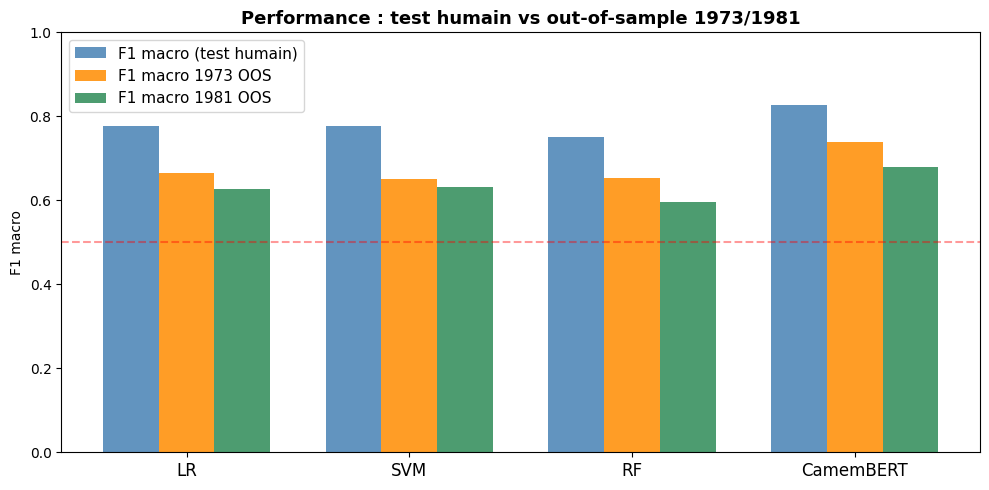

In [26]:
# Visualisation : dégradation F1 macro par modèle et année
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
modeles = ['LR', 'SVM', 'RF', 'CamemBERT']
cols_plot  = ['F1m humain', 'F1m 1973', 'F1m 1981']
labels_plot = ['F1 macro (test humain)', 'F1 macro 1973 OOS', 'F1 macro 1981 OOS']
colors = ['steelblue', 'darkorange', 'seagreen']
width = 0.25

for i, (col, color, lbl) in enumerate(zip(cols_plot, colors, labels_plot)):
    vals = [df_perf.loc[m, col] if col in df_perf.columns else 0 for m in modeles]
    ax.bar(x + i*width, vals, width, label=lbl, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(modeles, fontsize=12)
ax.set_ylabel('F1 macro')
ax.set_ylim(0, 1)
ax.set_title('Performance : test humain vs out-of-sample 1973/1981', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='Baseline aléatoire')
plt.tight_layout()
plt.show()

---
## Section III — Performance par courant politique

In [27]:
# F1 par courant politique — meilleur modèle baseline (LR)
def f1_par_courant(df, preds, modele_label, year):
    df = df.copy()
    df['pred'] = preds
    rows = []
    for courant in sorted(df['Courant Politique'].unique()):
        sub = df[df['Courant Politique'] == courant]
        if len(sub) < 5:
            continue
        f1 = f1_score(sub['Label'], sub['pred'], average='macro', zero_division=0)
        acc = accuracy_score(sub['Label'], sub['pred'])
        rows.append({'Courant': courant, 'N': len(sub), 'F1 macro': round(f1, 3), 'Accuracy': round(acc, 3)})
    result = pd.DataFrame(rows).set_index('Courant')
    print(f'\n--- {modele_label} sur {year} ---')
    print(result.to_string())
    return result

for year, df_oos in [(1973, df_1973), (1981, df_1981)]:
    f1_par_courant(df_oos, results_oos[year]['LR'], 'LR', year)
    f1_par_courant(df_oos, results_oos[year]['CamemBERT'], 'CamemBERT', year)


--- LR sur 1973 ---
          N  F1 macro  Accuracy
Courant                        
C        48     0.580     0.646
D        38     0.583     0.711
DR       32     0.407     0.688
G        29     0.637     0.793
GR       46     0.808     0.870
I        59     0.760     0.797

--- CamemBERT sur 1973 ---
          N  F1 macro  Accuracy
Courant                        
C        48     0.787     0.854
D        38     0.593     0.684
DR       32     0.475     0.906
G        29     0.594     0.828
GR       46     0.808     0.913
I        59     0.813     0.864

--- LR sur 1981 ---
           N  F1 macro  Accuracy
Courant                         
C         38     0.490     0.711
D         26     0.629     0.769
DR        13     0.458     0.846
G         16     0.547     0.562
GR       129     0.665     0.775
I         40     0.551     0.675

--- CamemBERT sur 1981 ---
           N  F1 macro  Accuracy
Courant                         
C         38     0.415     0.711
D         26     0.752     

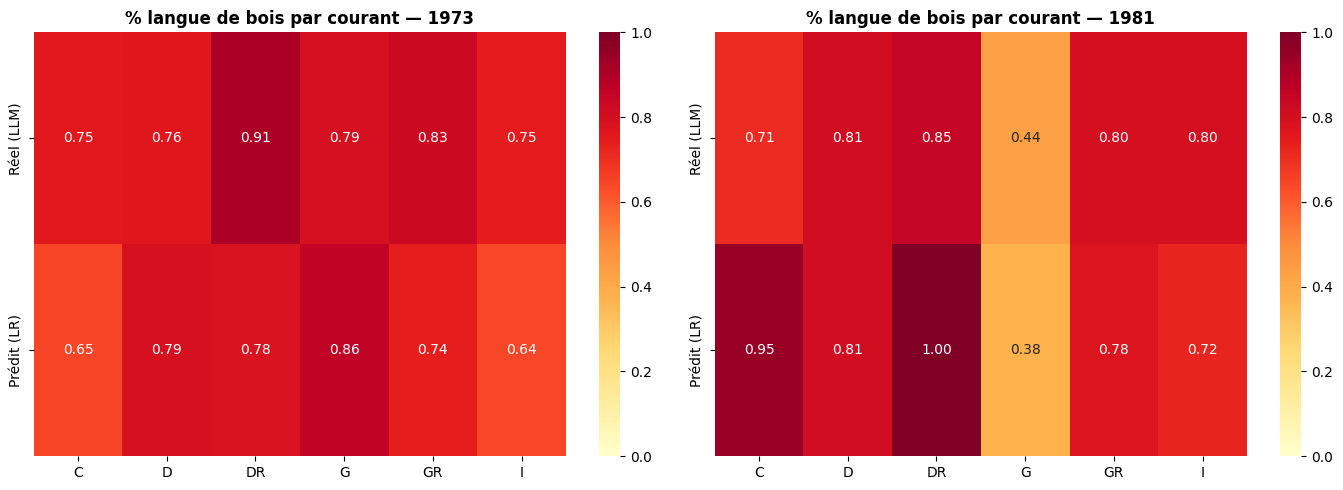

In [28]:
# Heatmap : taux de langue de bois prédit vs réel par courant
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (year, df_oos) in zip(axes, [(1973, df_1973), (1981, df_1981)]):
    df_tmp = df_oos.copy()
    df_tmp['pred_lr'] = results_oos[year]['LR']
    courants = sorted(df_tmp['Courant Politique'].unique())
    data = pd.DataFrame({
        'Réel (LLM)':  [df_tmp[df_tmp['Courant Politique']==c]['Label'].mean() for c in courants],
        'Prédit (LR)': [df_tmp[df_tmp['Courant Politique']==c]['pred_lr'].mean() for c in courants],
    }, index=courants)
    sns.heatmap(data.T, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1, ax=ax)
    ax.set_title(f'% langue de bois par courant — {year}', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Section IV — Analyse du décalage de distribution (covariate shift)

In [29]:
# 4.1 — Shift lexical : taux de tokens OOV par rapport au vocabulaire TF-IDF humain
tfidf_humain = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.95)
tfidf_humain.fit(df_train['texte_lemmatise'].fillna(''))
vocab_train = set(tfidf_humain.vocabulary_.keys())

def oov_rate(textes, vocab):
    rates = []
    for t in textes:
        tokens = str(t).split()
        if not tokens:
            continue
        oov = sum(1 for tok in tokens if tok not in vocab)
        rates.append(oov / len(tokens))
    return np.mean(rates) if rates else 0

print('Taux OOV par rapport au vocabulaire TF-IDF du train humain :')
for label, df_oos in [('Humain (test)', df_test_humain), ('1973 (OOS)', df_1973), ('1981 (OOS)', df_1981)]:
    rate = oov_rate(df_oos['texte_lemmatise'].fillna(''), vocab_train)
    print(f'  {label} : {rate*100:.1f}% de tokens absents du vocab humain')

Taux OOV par rapport au vocabulaire TF-IDF du train humain :
  Humain (test) : 27.3% de tokens absents du vocab humain
  1973 (OOS) : 27.6% de tokens absents du vocab humain
  1981 (OOS) : 25.5% de tokens absents du vocab humain


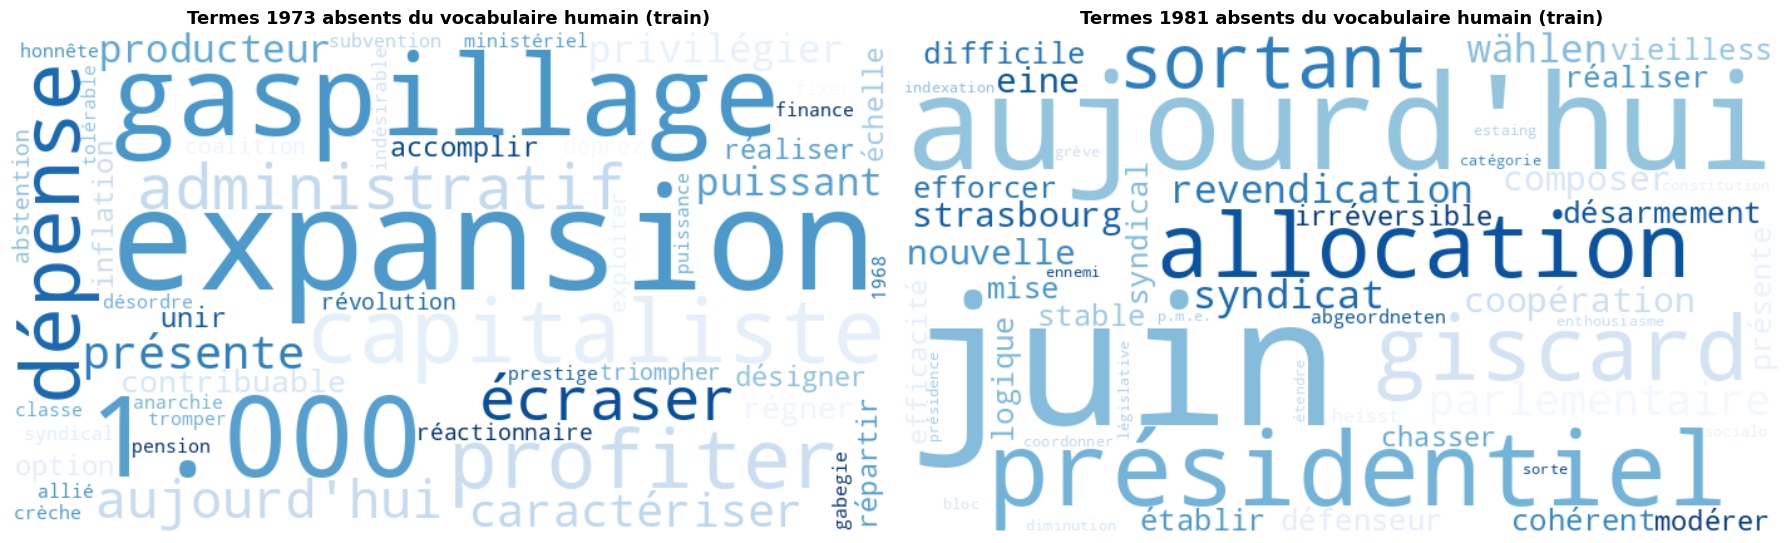

In [30]:
# Wordclouds : termes spécifiques à 1973/1981 absents du vocabulaire du train humain
def top_oov_words(df_oos, vocab_ref, top_n=50):
    counter = {}
    for t in df_oos['texte_lemmatise'].dropna():
        for tok in str(t).split():
            if tok not in vocab_ref and len(tok) > 3:
                counter[tok] = counter.get(tok, 0) + 1
    return dict(sorted(counter.items(), key=lambda x: x[1], reverse=True)[:top_n])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, (year, df_oos) in zip(axes, [(1973, df_1973), (1981, df_1981)]):
    oov_words = top_oov_words(df_oos, vocab_train)
    if oov_words:
        wc = WordCloud(width=700, height=400, background_color='white', colormap='Blues')
        wc.generate_from_frequencies(oov_words)
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Termes {year} absents du vocabulaire humain (train)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

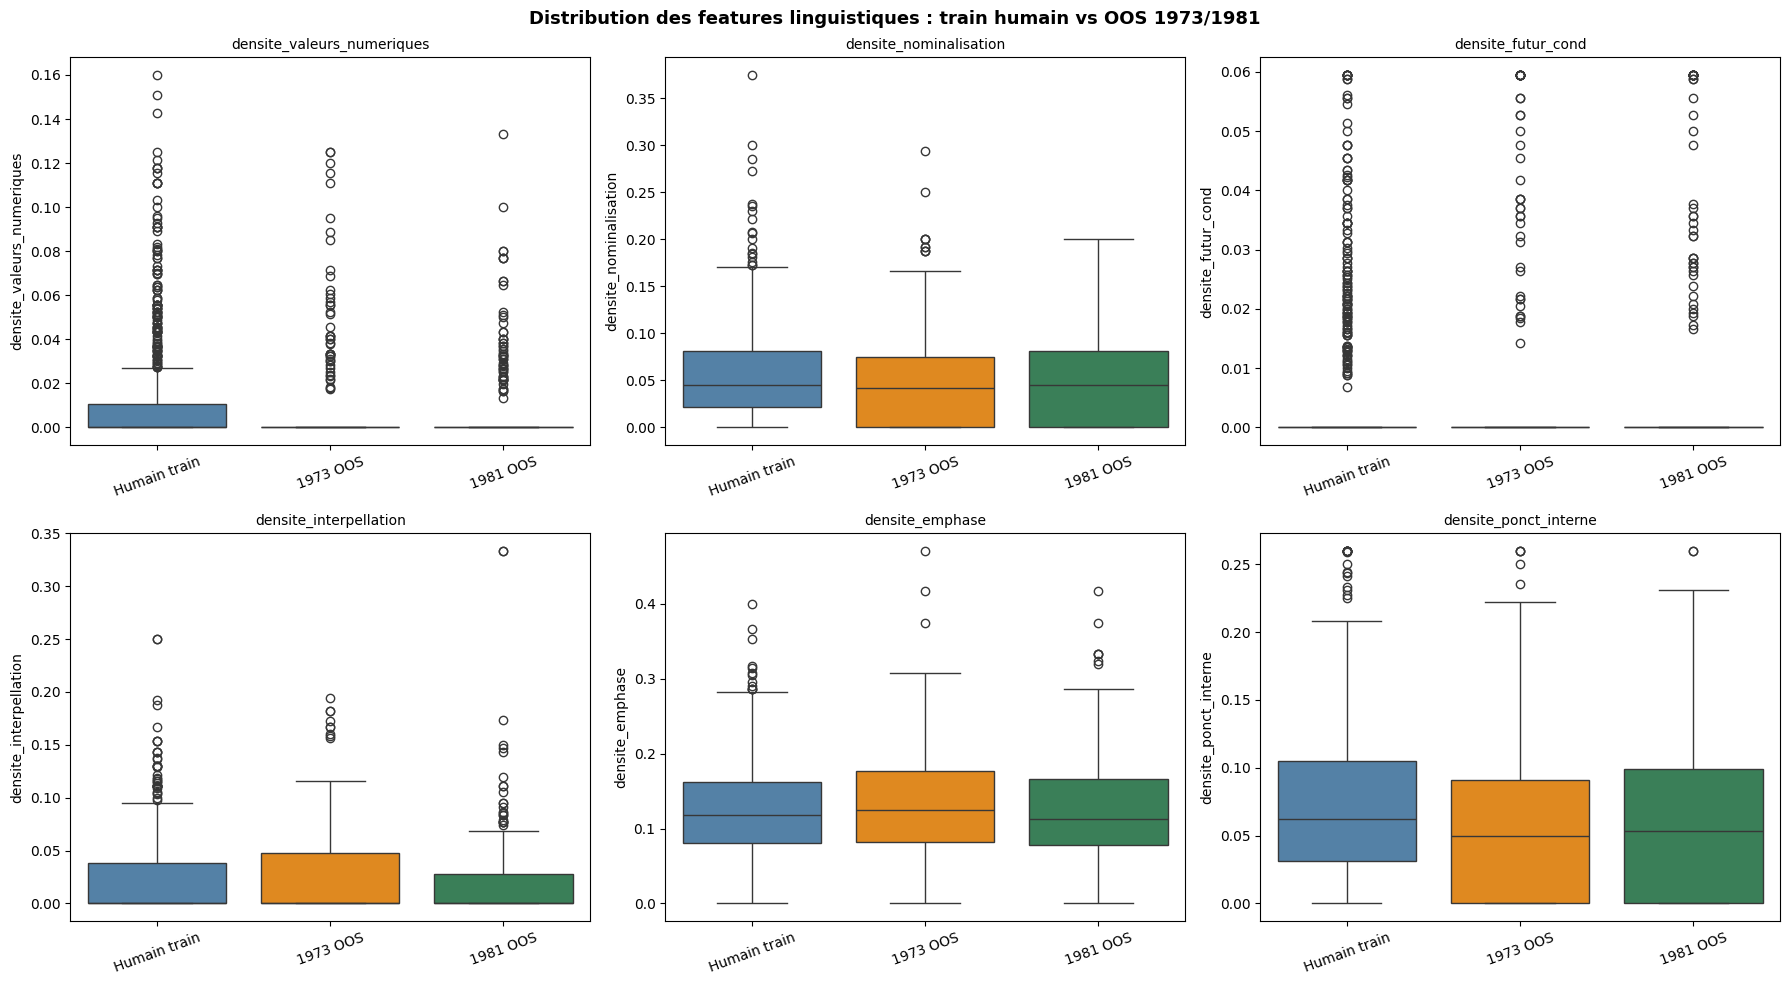

In [31]:
# 4.2 — Shift des features linguistiques : boxplots comparatifs
feats_plot = [f for f in features_significatives if f != 'texte_lemmatise' and f in df_humain.columns]
df_all = pd.concat([
    df_train[feats_plot + ['Label']].assign(annee='Humain train'),
    df_1973[feats_plot + ['Label']].assign(annee='1973 OOS'),
    df_1981[feats_plot + ['Label']].assign(annee='1981 OOS'),
], ignore_index=True)

n_feats = len(feats_plot)
ncols = 3
nrows = (n_feats + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5*nrows))
axes_flat = axes.flatten()

for i, feat in enumerate(feats_plot):
    sns.boxplot(data=df_all, x='annee', y=feat, ax=axes_flat[i],
                palette={'Humain train': 'steelblue', '1973 OOS': 'darkorange', '1981 OOS': 'seagreen'})
    axes_flat[i].set_title(feat, fontsize=10)
    axes_flat[i].set_xlabel('')
    axes_flat[i].tick_params(axis='x', rotation=20)

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Distribution des features linguistiques : train humain vs OOS 1973/1981',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# Tests Mann-Whitney : 1993 train vs 1973 et 1981
print('Tests Mann-Whitney (shift de distribution par rapport à 1993 train) :')
rows_shift = []
for feat in feats_plot:
    g_train = df_train[feat].dropna()
    row = {'Feature': feat}
    for year, df_oos in [(1973, df_1973), (1981, df_1981)]:
        g_oos = df_oos[feat].dropna()
        _, p = mannwhitneyu(g_train, g_oos, alternative='two-sided')
        delta_median = df_oos[feat].median() - df_train[feat].median()
        row[f'p vs {year}'] = round(p, 4)
        row[f'Δmediane {year}'] = round(delta_median, 4)
    rows_shift.append(row)

df_shift = pd.DataFrame(rows_shift).set_index('Feature')
print(df_shift.to_string())

Tests Mann-Whitney (shift de distribution par rapport à 1993 train) :
                            p vs 1973  Δmediane 1973  p vs 1981  Δmediane 1981
Feature                                                                       
densite_valeurs_numeriques     0.0273         0.0000     0.1332         0.0000
densite_nominalisation         0.0928        -0.0038     0.6092         0.0000
densite_futur_cond             0.8945         0.0000     0.8230         0.0000
densite_interpellation         0.4807         0.0000     0.0009         0.0000
densite_emphase                0.1601         0.0074     0.9108        -0.0055
densite_ponct_interne          0.0008        -0.0131     0.0051        -0.0092


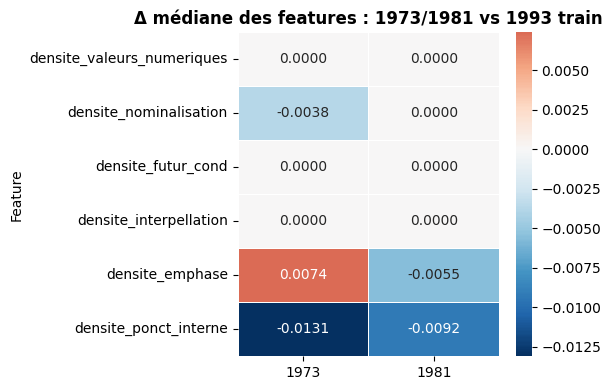

In [33]:
# Heatmap du shift de médiane
delta_cols = [c for c in df_shift.columns if 'Δmediane' in c]
df_delta = df_shift[delta_cols].rename(columns=lambda c: c.replace('Δmediane ', ''))

plt.figure(figsize=(6, max(4, len(feats_plot)*0.6)))
sns.heatmap(df_delta, annot=True, fmt='.4f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Δ médiane des features : 1973/1981 vs 1993 train', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
# 4.3 — Pouvoir discriminant de ratio_concretude_lexicale par dataset
if 'ratio_concretude_lexicale' in df_humain.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
    for ax, (label, df_oos) in zip(axes, [('Humain (test)', df_test_humain),
                                           ('1973 (OOS)', df_1973),
                                           ('1981 (OOS)', df_1981)]):
        for lbl_val, color in [(0, 'steelblue'), (1, 'darkorange')]:
            subset = df_oos[df_oos['Label'] == lbl_val]['ratio_concretude_lexicale'].dropna()
            ax.hist(subset, bins=20, alpha=0.6, color=color,
                    label=f'{"Concret" if lbl_val==0 else "Langue de bois"} (n={len(subset)})')
        ax.set_title(f'ratio_concretude_lexicale — {label}', fontweight='bold')
        ax.set_xlabel('Ratio (0=LDB, 1=Concret)')
        ax.legend(fontsize=9)
    plt.suptitle('Pouvoir discriminant de ratio_concretude_lexicale\n(feature construite sur vocab humain train)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Section V — Analyse des erreurs et déterminants

In [35]:
# 5.1 — Faux positifs / faux négatifs par année (LR et CamemBERT)
for year, df_oos in [(1973, df_1973), (1981, df_1981)]:
    for modele in ['LR', 'CamemBERT']:
        df_err = df_oos.copy().reset_index(drop=True)
        df_err['pred'] = results_oos[year][modele]
        fp = df_err[(df_err['Label'] == 0) & (df_err['pred'] == 1)]
        fn = df_err[(df_err['Label'] == 1) & (df_err['pred'] == 0)]
        print(f'\n=== {year} — {modele} ===')
        print(f'Faux positifs (concret → prédit LDB) : {len(fp)} ({len(fp)/len(df_oos)*100:.1f}%)')
        for _, r in fp.head(2).iterrows():
            print(f'  [{r["Courant Politique"]}] {str(r["Texte"])[:120]}...')
        print(f'Faux négatifs (LDB → prédit concret) : {len(fn)} ({len(fn)/len(df_oos)*100:.1f}%)')
        for _, r in fn.head(2).iterrows():
            print(f'  [{r["Courant Politique"]}] {str(r["Texte"])[:120]}...')


=== 1973 — LR ===
Faux positifs (concret → prédit LDB) : 23 (9.1%)
  [I] Au premier tour vous avez été 49.616 électrices et électeurs de la 8e Circonscription à avoir affirmé nettement votre vo...
  [D] L'expansion est plus mal gérée en France que dans les autres pays industriels concurrents. Les privilégiés accentuent le...
Faux négatifs (LDB → prédit concret) : 39 (15.5%)
  [I] Je me présente à vous avec l'expérience acquise dans l'exercice de responsabilités publiques et administratives au servi...
  [I] Notre projet repose sur le renforcement des services publics et une meilleure répartition des ressources entre les terri...

=== 1973 — CamemBERT ===
Faux positifs (concret → prédit LDB) : 27 (10.7%)
  [I] Au premier tour vous avez été 49.616 électrices et électeurs de la 8e Circonscription à avoir affirmé nettement votre vo...
  [D] L'expansion est plus mal gérée en France que dans les autres pays industriels concurrents. Les privilégiés accentuent le...
Faux négatifs (LDB → prédi

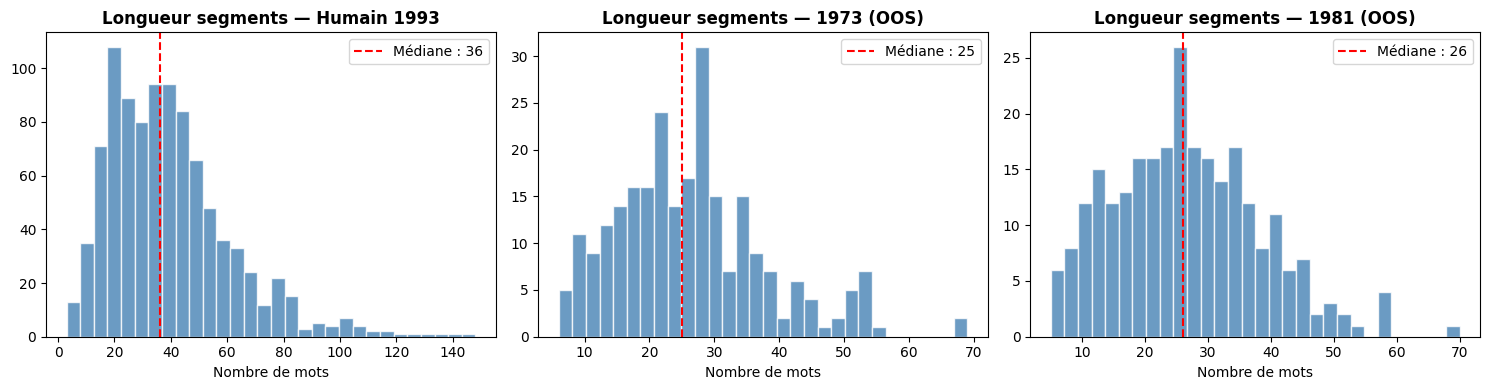

Médiane mots/segment :
  Humain 1993 : 36.0
  1973 OOS : 25.0
  1981 OOS : 26.0


In [36]:
# 5.2 — Distribution de la longueur des segments par dataset
for df_oos in [df_humain, df_1973, df_1981]:
    df_oos['n_mots'] = df_oos['Texte'].apply(lambda t: len(str(t).split()))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (label, df_oos) in zip(axes, [('Humain 1993', df_humain), ('1973 (OOS)', df_1973), ('1981 (OOS)', df_1981)]):
    ax.hist(df_oos['n_mots'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df_oos['n_mots'].median(), color='red', linestyle='--',
               label=f'Médiane : {df_oos["n_mots"].median():.0f}')
    ax.set_title(f'Longueur segments — {label}', fontweight='bold')
    ax.set_xlabel('Nombre de mots')
    ax.legend()
plt.tight_layout()
plt.show()

print('Médiane mots/segment :')
for label, df_oos in [('Humain 1993', df_humain), ('1973 OOS', df_1973), ('1981 OOS', df_1981)]:
    print(f'  {label} : {df_oos["n_mots"].median():.1f}')

In [37]:
# Corrélation longueur × taux d'erreur
print('Corrélation longueur (n_mots) × erreur (LR) :')
for year, df_oos in [(1973, df_1973), (1981, df_1981)]:
    df_tmp = df_oos.copy()
    df_tmp['pred'] = results_oos[year]['LR']
    df_tmp['erreur'] = (df_tmp['Label'] != df_tmp['pred']).astype(int)
    corr = df_tmp[['n_mots', 'erreur']].corr().loc['n_mots', 'erreur']
    print(f'  {year} : r = {corr:.3f}')
    
    # Taux d'erreur par quartile de longueur
    df_tmp['quartile_longueur'] = pd.qcut(df_tmp['n_mots'], q=4, labels=['Q1 (court)', 'Q2', 'Q3', 'Q4 (long)'])
    print(df_tmp.groupby('quartile_longueur', observed=True)['erreur'].mean().rename('taux_erreur').round(3).to_string())

Corrélation longueur (n_mots) × erreur (LR) :
  1973 : r = -0.028
quartile_longueur
Q1 (court)    0.224
Q2            0.267
Q3            0.266
Q4 (long)     0.230
  1981 : r = -0.102
quartile_longueur
Q1 (court)    0.333
Q2            0.213
Q3            0.310
Q4 (long)     0.190


In [38]:
# 5.3 — Régression logistique des erreurs : quels déterminants ?
from sklearn.linear_model import LogisticRegression as LR_sklearn

feats_reg = [f for f in feats_plot if f in df_1973.columns]

for year, df_oos in [(1973, df_1973), (1981, df_1981)]:
    df_reg = df_oos.copy()
    df_reg['pred_lr'] = results_oos[year]['LR']
    df_reg['erreur'] = (df_reg['Label'] != df_reg['pred_lr']).astype(int)
    df_reg['n_mots'] = df_reg['Texte'].apply(lambda t: len(str(t).split()))
    
    # Encodage courant politique
    courant_dummies = pd.get_dummies(df_reg['Courant Politique'], prefix='courant', drop_first=True)
    X_reg = pd.concat([
        df_reg[feats_reg + ['n_mots']].fillna(0),
        courant_dummies
    ], axis=1).values
    y_reg = df_reg['erreur'].values
    
    model_reg = LR_sklearn(max_iter=1000, random_state=42)
    model_reg.fit(X_reg, y_reg)
    
    feature_names = feats_reg + ['n_mots'] + list(courant_dummies.columns)
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model_reg.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False)
    
    print(f'\n=== Déterminants des erreurs du LR — {year} ===')
    print(f'(coeff. positif = augmente les erreurs)')
    print(coef_df.head(8).to_string(index=False))


=== Déterminants des erreurs du LR — 1973 ===
(coeff. positif = augmente les erreurs)
                   Feature  Coefficient
                courant_GR    -0.930999
    densite_nominalisation     0.744011
           densite_emphase    -0.719234
                 courant_I    -0.527553
                 courant_G    -0.447163
    densite_interpellation    -0.386920
     densite_ponct_interne    -0.384453
densite_valeurs_numeriques    -0.216979

=== Déterminants des erreurs du LR — 1981 ===
(coeff. positif = augmente les erreurs)
                   Feature  Coefficient
    densite_interpellation    -0.510762
                courant_DR    -0.497576
                courant_GR    -0.352029
                 courant_G     0.347765
                 courant_D    -0.236613
           densite_emphase    -0.154417
densite_valeurs_numeriques     0.133893
        densite_futur_cond    -0.104688


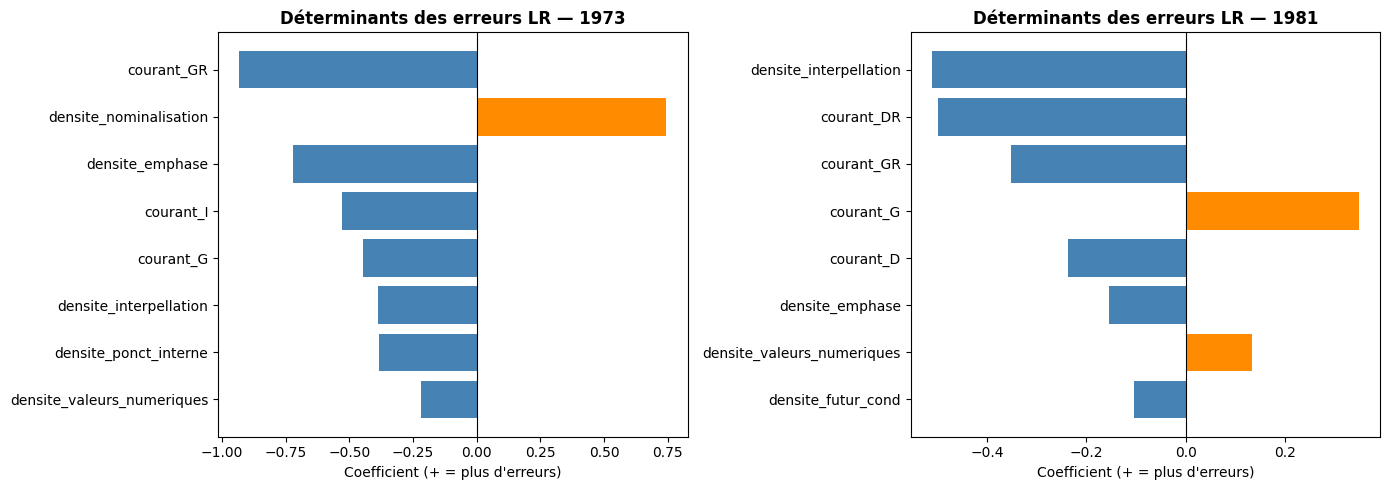

In [39]:
# Visualisation des coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (year, df_oos) in zip(axes, [(1973, df_1973), (1981, df_1981)]):
    df_reg = df_oos.copy()
    df_reg['pred_lr'] = results_oos[year]['LR']
    df_reg['erreur'] = (df_reg['Label'] != df_reg['pred_lr']).astype(int)
    df_reg['n_mots'] = df_reg['Texte'].apply(lambda t: len(str(t).split()))
    courant_dummies = pd.get_dummies(df_reg['Courant Politique'], prefix='courant', drop_first=True)
    X_reg = pd.concat([df_reg[feats_reg + ['n_mots']].fillna(0), courant_dummies], axis=1).values
    y_reg = df_reg['erreur'].values
    
    model_reg = LR_sklearn(max_iter=1000, random_state=42)
    model_reg.fit(X_reg, y_reg)
    
    feature_names = feats_reg + ['n_mots'] + list(courant_dummies.columns)
    coef_df = pd.DataFrame({'Feature': feature_names, 'Coeff': model_reg.coef_[0]})
    coef_df = coef_df.reindex(coef_df['Coeff'].abs().sort_values(ascending=True).index).tail(8)
    
    colors = ['darkorange' if c > 0 else 'steelblue' for c in coef_df['Coeff']]
    ax.barh(coef_df['Feature'], coef_df['Coeff'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Déterminants des erreurs LR — {year}', fontweight='bold')
    ax.set_xlabel('Coefficient (+ = plus d\'erreurs)')

plt.tight_layout()
plt.show()

In [40]:
# 5.4 — Synthèse
print('\n' + '='*65)
print('SYNTHÈSE — Généralisation des modèles (train humain 1993 → OOS 1973/1981)')
print('='*65)
print()

print('1. Performance F1 macro :')
print(df_perf[['F1m humain', 'F1m 1973', 'F1m 1981']].to_string())
print()

print('2. OOV rate (tokens hors vocabulaire TF-IDF train humain) :')
for label, df_oos in [('Humain (test)', df_test_humain), ('1973 OOS', df_1973), ('1981 OOS', df_1981)]:
    rate = oov_rate(df_oos['texte_lemmatise'].fillna(''), vocab_train)
    print(f'   {label} : {rate*100:.1f}%')

print()
print('3. Features avec shift significatif (Mann-Whitney p<0.05 vs train humain) :')
for year in [1973, 1981]:
    sig = df_shift[df_shift[f'p vs {year}'] < 0.05].index.tolist()
    print(f'   {year} : {sig}')

print('='*65)


SYNTHÈSE — Généralisation des modèles (train humain 1993 → OOS 1973/1981)

1. Performance F1 macro :
           F1m humain  F1m 1973  F1m 1981
Modèle                                   
LR              0.777     0.665     0.628
SVM             0.777     0.650     0.631
RF              0.750     0.653     0.596
CamemBERT       0.827     0.738     0.680

2. OOV rate (tokens hors vocabulaire TF-IDF train humain) :
   Humain (test) : 27.3%
   1973 OOS : 27.6%
   1981 OOS : 25.5%

3. Features avec shift significatif (Mann-Whitney p<0.05 vs train humain) :
   1973 : ['densite_valeurs_numeriques', 'densite_ponct_interne']
   1981 : ['densite_interpellation', 'densite_ponct_interne']


---
## Section VI — Analyses complémentaires

### A) Correction du prior shift (ajustement du seuil)
### B) Analyse thématique des erreurs (FN : langue de bois manquée)
### C) Évolution inter-temporelle du taux de LDB par courant politique

=== Impact de l'ajustement du seuil (LR) ===

1973 — seuil 0.5 : F1m=0.665 | seuil optimal (0.54) : F1m=0.683 (+0.018)
1981 — seuil 0.5 : F1m=0.628 | seuil optimal (0.34) : F1m=0.663 (+0.035)


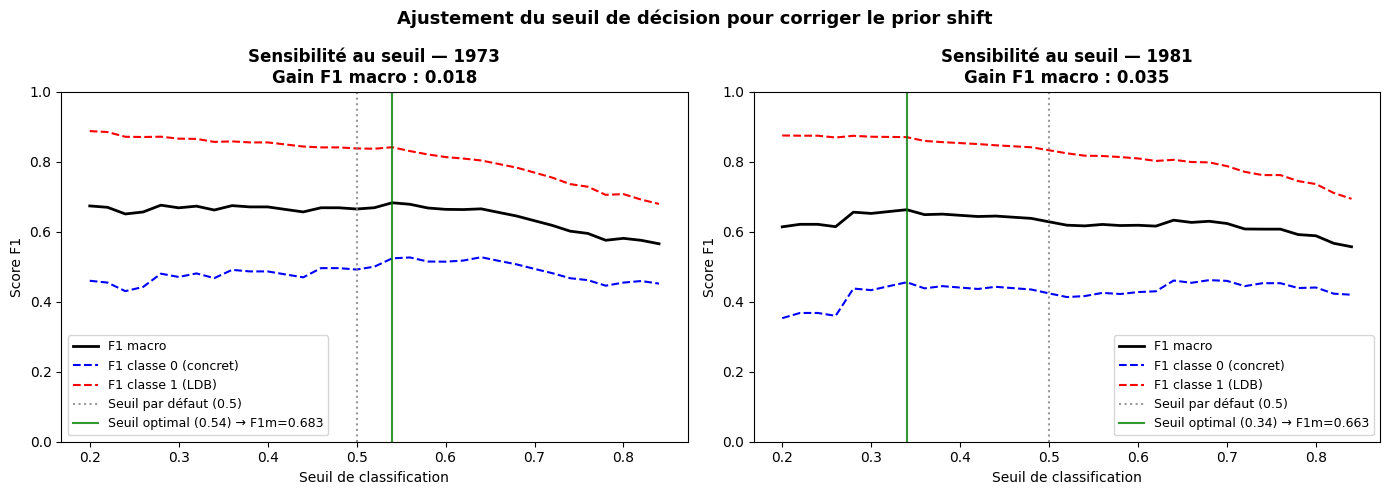

In [44]:
# A) Prior shift — le taux de LDB est plus élevé en 1973/1981 (79%, 77%) qu'en 1993 (69%)
# On ajuste le seuil de décision de LR (qui donne des probas) pour chaque dataset OOS
# et on mesure si ça récupère de la F1 sur la classe 0

from sklearn.calibration import calibration_curve

# Probas LR sur les datasets OOS (LR via decision_function → on utilise predict_proba)
# On re-pipeline avec probability=True
pipeline_lr_proba = Pipeline([
    ('pre', preprocesseur),
    ('clf', LogisticRegression(max_iter=3000, random_state=42, class_weight='balanced',
                               solver='liblinear', C=gs_lr.best_params_['clf__C'],
                               penalty=gs_lr.best_params_['clf__penalty']))
])
pipeline_lr_proba.fit(df_train, df_train['Label'])

print('=== Impact de l\'ajustement du seuil (LR) ===\n')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (year, df_oos) in zip(axes, [(1973, df_1973), (1981, df_1981)]):
    probas = pipeline_lr_proba.predict_proba(df_oos)[:, 1]
    y_true = df_oos['Label'].values

    # Seuil par défaut (0.5)
    thresholds = np.arange(0.2, 0.85, 0.02)
    f1_macros, f1_c0s, f1_c1s = [], [], []
    for t in thresholds:
        preds = (probas >= t).astype(int)
        f1_macros.append(f1_score(y_true, preds, average='macro', zero_division=0))
        f1s = f1_score(y_true, preds, average=None, zero_division=0)
        f1_c0s.append(f1s[0])
        f1_c1s.append(f1s[1])

    best_idx = np.argmax(f1_macros)
    best_t = thresholds[best_idx]

    ax.plot(thresholds, f1_macros, 'k-', linewidth=2, label='F1 macro')
    ax.plot(thresholds, f1_c0s, 'b--', linewidth=1.5, label='F1 classe 0 (concret)')
    ax.plot(thresholds, f1_c1s, 'r--', linewidth=1.5, label='F1 classe 1 (LDB)')
    ax.axvline(0.5, color='gray', linestyle=':', alpha=0.8, label='Seuil par défaut (0.5)')
    ax.axvline(best_t, color='green', linestyle='-', alpha=0.8,
               label=f'Seuil optimal ({best_t:.2f}) → F1m={f1_macros[best_idx]:.3f}')
    ax.set_title(f'Sensibilité au seuil — {year}\n'
                 f'Gain F1 macro : {f1_macros[best_idx] - f1_macros[np.argmin(abs(thresholds - 0.5))]:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Seuil de classification')
    ax.set_ylabel('Score F1')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

    print(f'{year} — seuil 0.5 : F1m={f1_macros[np.argmin(abs(thresholds-0.5))]:.3f} | '
          f'seuil optimal ({best_t:.2f}) : F1m={f1_macros[best_idx]:.3f} '
          f'(+{f1_macros[best_idx] - f1_macros[np.argmin(abs(thresholds-0.5))]:.3f})')

plt.suptitle('Ajustement du seuil de décision pour corriger le prior shift', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== B) Patterns lexicaux des faux négatifs ===

1973 — 39 FN (15.5%) | 160 TP1
  Top termes sur-représentés dans les FN : ['moyen', 'service', 'artisan', 'commerçant', 'dépense', 'plan', 'équipement', 'écraser', 'rural', 'aide']
1981 — 32 FN (12.2%) | 169 TP1
  Top termes sur-représentés dans les FN : ['développer', 'emploi', 'mesure', 'région', 'individuel', 'favoriser', 'création', 'entreprise', 'chômage', 'inégalité']


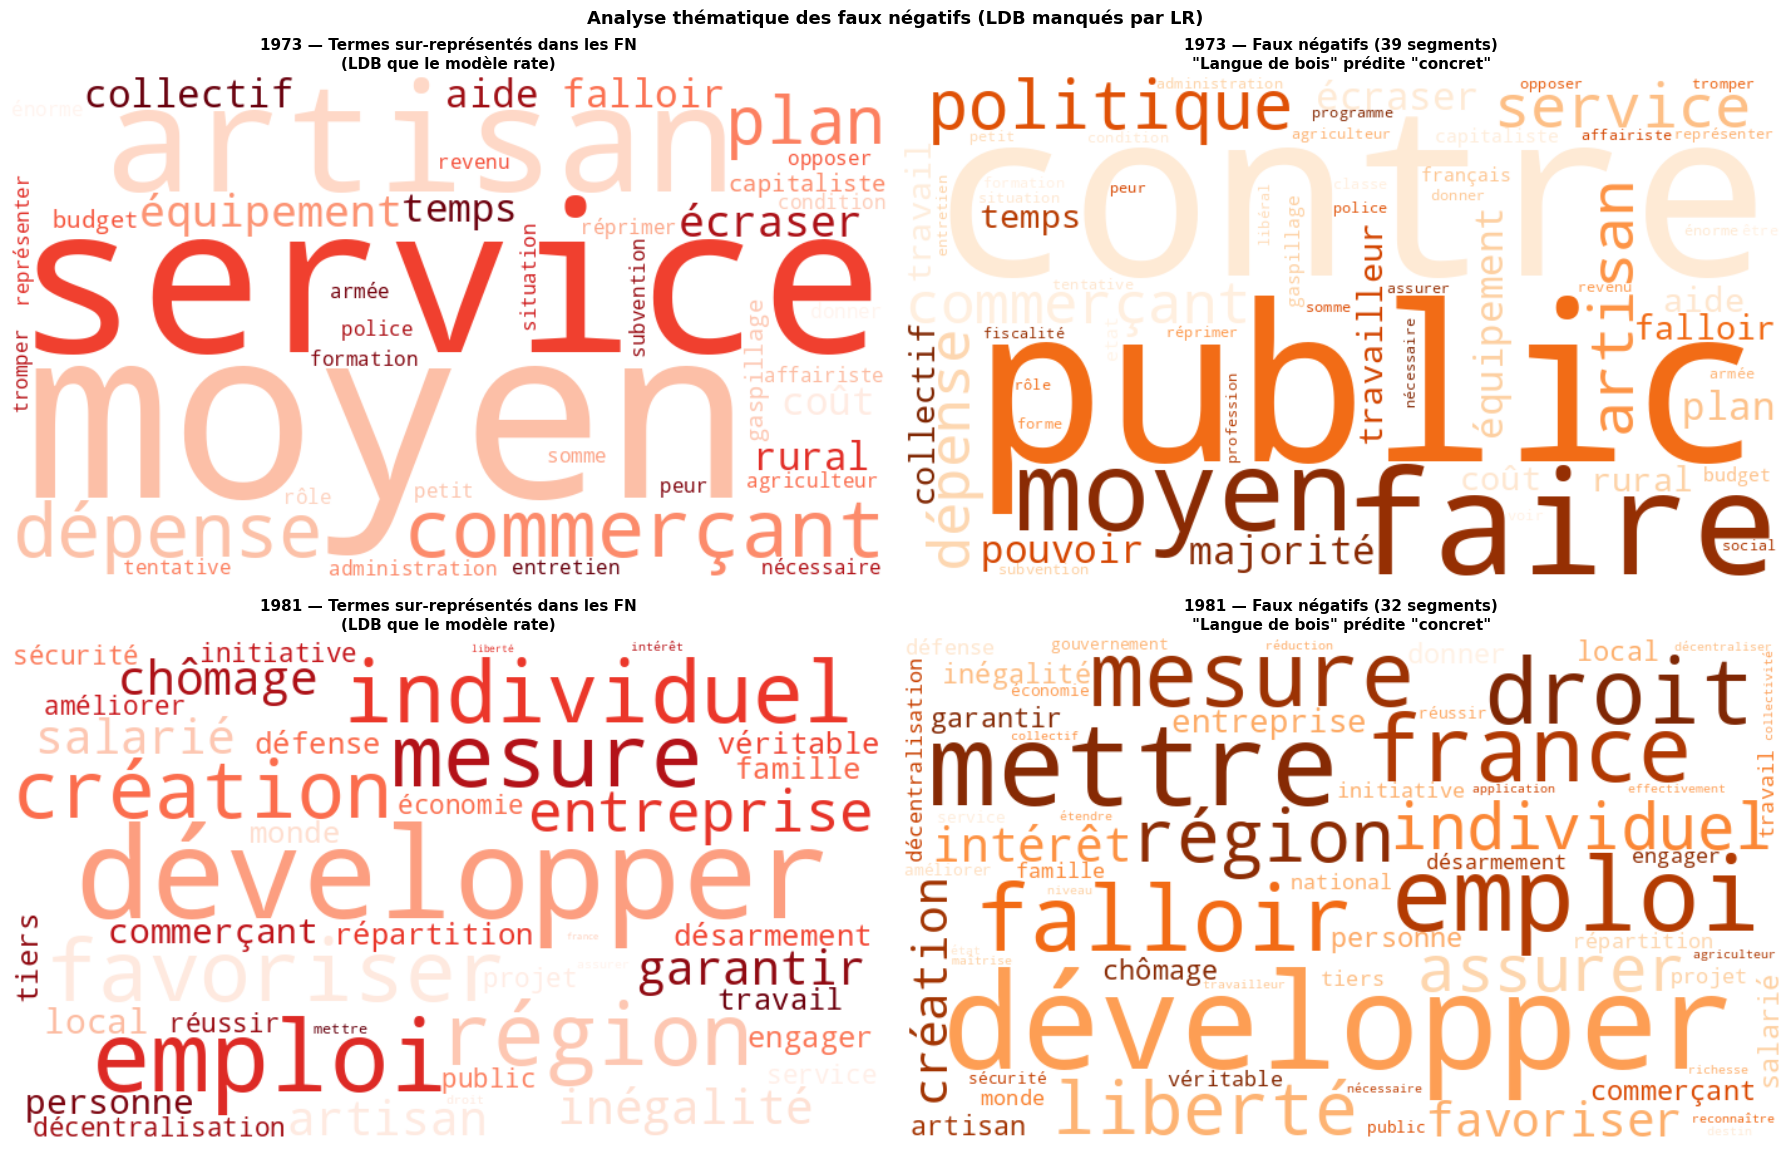

In [45]:
# B) Analyse thématique des faux négatifs (LDB prédits "concret")
# On cherche les mots les plus fréquents dans les FN vs les vrais positifs LDB
# pour comprendre quel "type" de langue de bois échappe au modèle

print('=== B) Patterns lexicaux des faux négatifs ===\n')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for row_ax, (year, df_oos) in zip(axes, [(1973, df_1973), (1981, df_1981)]):
    df_tmp = df_oos.copy().reset_index(drop=True)
    df_tmp['pred_lr'] = results_oos[year]['LR']

    fn  = df_tmp[(df_tmp['Label'] == 1) & (df_tmp['pred_lr'] == 0)]  # LDB manqués
    tp1 = df_tmp[(df_tmp['Label'] == 1) & (df_tmp['pred_lr'] == 1)]  # LDB bien classés

    def freq_dict(textes, top_n=60):
        counter = {}
        for t in textes:
            for tok in str(t).split():
                if len(tok) > 3:
                    counter[tok] = counter.get(tok, 0) + 1
        return dict(sorted(counter.items(), key=lambda x: x[1], reverse=True)[:top_n])

    freq_fn  = freq_dict(fn['texte_lemmatise'].fillna(''))
    freq_tp1 = freq_dict(tp1['texte_lemmatise'].fillna(''))

    # Termes sur-représentés dans les FN (normalisé par fréquence)
    n_fn, n_tp = max(len(fn), 1), max(len(tp1), 1)
    specifiques_fn = {
        w: (freq_fn.get(w, 0) / n_fn) / (freq_tp1.get(w, 0.5) / n_tp)
        for w in freq_fn if freq_fn.get(w, 0) >= 2
    }
    specifiques_fn = dict(sorted(specifiques_fn.items(), key=lambda x: x[1], reverse=True)[:40])

    for ax, (d, title, cmap) in zip(row_ax, [
        (specifiques_fn, f'{year} — Termes sur-représentés dans les FN\n(LDB que le modèle rate)', 'Reds'),
        (freq_fn, f'{year} — Faux négatifs ({len(fn)} segments)\n"Langue de bois" prédite "concret"', 'Oranges'),
    ]):
        if d:
            wc = WordCloud(width=700, height=400, background_color='white', colormap=cmap)
            wc.generate_from_frequencies(d)
            ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(title, fontsize=11, fontweight='bold')

    print(f'{year} — {len(fn)} FN ({len(fn)/len(df_oos)*100:.1f}%) | {len(tp1)} TP1')
    print(f'  Top termes sur-représentés dans les FN : {list(specifiques_fn.keys())[:10]}')

plt.suptitle('Analyse thématique des faux négatifs (LDB manqués par LR)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== C) Évolution du taux de LDB par courant (1973 → 1981 → 1993) ===

Taux de langue de bois (%) par courant et par année :
          C     D    DR     G    GR     I
Année                                    
1973   75.0  76.3  90.6  79.3  82.6  74.6
1981   71.1  80.8  84.6  43.8  79.8  80.0
1993   72.4  84.0  51.0  70.9  66.9  33.3


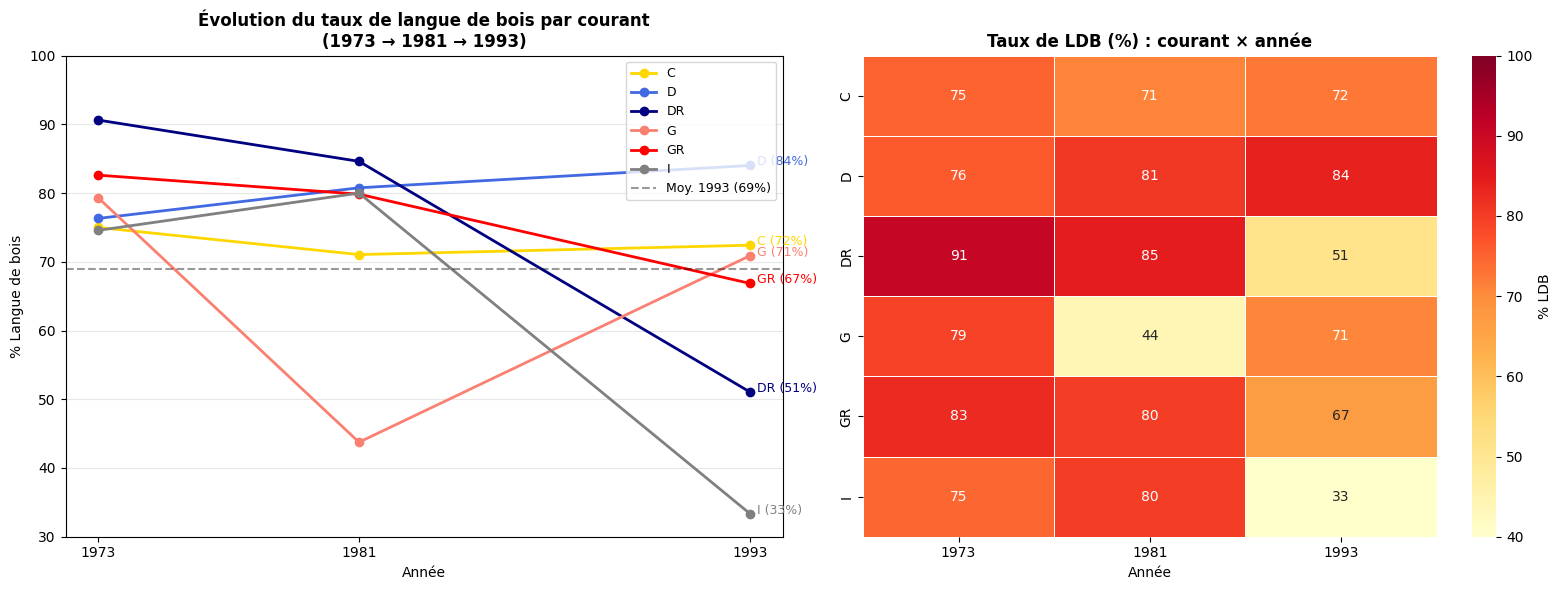


Évolution 1973 → 1993 (positif = plus de LDB en 1993) :
  C : 75% → 72% (▼ 3 pts)
  D : 76% → 84% (▲ 8 pts)
  DR : 91% → 51% (▼ 40 pts)
  G : 79% → 71% (▼ 8 pts)
  GR : 83% → 67% (▼ 16 pts)
  I : 75% → 33% (▼ 41 pts)


In [46]:
# C) Évolution inter-temporelle du taux de LDB par courant politique
# Compare les taux réels (annotés LLM/humain) et prédits sur 1973, 1981, 1993
# pour chaque courant — qui devient plus/moins "en bois" au fil du temps ?

print('=== C) Évolution du taux de LDB par courant (1973 → 1981 → 1993) ===\n')

# Données réelles annotées
courants_communs = ['C', 'D', 'DR', 'G', 'GR', 'I']

taux_reel = {}
for year, df_oos in [(1973, df_1973), (1981, df_1981), (1993, df_humain)]:
    taux_reel[year] = {}
    for c in courants_communs:
        sub = df_oos[df_oos['Courant Politique'] == c]
        if len(sub) >= 5:
            taux_reel[year][c] = sub['Label'].mean() * 100
        else:
            taux_reel[year][c] = np.nan

df_taux = pd.DataFrame(taux_reel).T
df_taux.index.name = 'Année'
print('Taux de langue de bois (%) par courant et par année :')
print(df_taux.round(1).to_string())

# Graphique évolution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Évolution par courant (lignes)
ax = axes[0]
colors_courant = {'GR': 'red', 'G': 'salmon', 'C': 'gold', 'D': 'royalblue', 'DR': 'navy', 'I': 'gray'}
for c in courants_communs:
    vals = [taux_reel[y].get(c, np.nan) for y in [1973, 1981, 1993]]
    if not all(np.isnan(v) for v in vals):
        ax.plot([1973, 1981, 1993], vals, marker='o', linewidth=2,
                color=colors_courant.get(c, 'black'), label=c)
        # Label à droite
        if not np.isnan(vals[-1]):
            ax.annotate(f'{c} ({vals[-1]:.0f}%)', (1993, vals[-1]),
                        xytext=(5, 0), textcoords='offset points', fontsize=9,
                        color=colors_courant.get(c, 'black'))

ax.axhline(df_humain['Label'].mean() * 100, color='black', linestyle='--', alpha=0.4,
           label=f'Moy. 1993 ({df_humain["Label"].mean()*100:.0f}%)')
ax.set_title('Évolution du taux de langue de bois par courant\n(1973 → 1981 → 1993)', fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('% Langue de bois')
ax.set_xticks([1973, 1981, 1993])
ax.set_ylim(30, 100)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Heatmap de synthèse
ax2 = axes[1]
df_heatmap = df_taux[courants_communs].T
sns.heatmap(df_heatmap, annot=True, fmt='.0f', cmap='YlOrRd', vmin=40, vmax=100,
            ax=ax2, linewidths=0.5, cbar_kws={'label': '% LDB'})
ax2.set_title('Taux de LDB (%) : courant × année', fontweight='bold')
ax2.set_xlabel('Année')

plt.tight_layout()
plt.show()

# Delta : qui s'est amélioré/dégradé entre 1973 et 1993 ?
print('\nÉvolution 1973 → 1993 (positif = plus de LDB en 1993) :')
for c in courants_communs:
    v73 = taux_reel[1973].get(c, np.nan)
    v93 = taux_reel[1993].get(c, np.nan)
    if not (np.isnan(v73) or np.isnan(v93)):
        delta = v93 - v73
        arrow = '▲' if delta > 0 else '▼'
        print(f'  {c} : {v73:.0f}% → {v93:.0f}% ({arrow} {abs(delta):.0f} pts)')